In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_excel("Retail_Sales_Dataset.csv.xlsx")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,City,State,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Payment_Method,Rating
0,10000,2025-02-05,C1000,Customer 1,Male,61,Delhi,Delhi State,North,Electronics,Keyboard,5,2106.0,5.0,10003.5,Cash,5.0
1,10001,2025-05-10,C1001,Customer 2,Male,53,Bengaluru,Bengaluru State,South,Electronics,Laptop,2,1891.0,5.0,3592.9,UPI,5.0
2,10002,2025-02-10,C1002,Customer 3,Female,39,Bengaluru,Bengaluru State,South,Clothing,Jeans,10,2378.0,0.0,23780.0,Credit Card,2.0
3,10003,2025-04-02,C1003,Customer 4,Female,20,Mumbai,Mumbai State,West,Furniture,Chair,2,3212.0,0.0,6424.0,Debit Card,5.0
4,10004,2025-04-03,C1004,Customer 5,Male,63,Delhi,Delhi State,North,Grocery,Rice,9,2501.0,20.0,18007.2,Cash,1.0


In [5]:
df.shape

(1040, 17)

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender',
       'Age', 'City', 'State', 'Region', 'Product_Category', 'Product_Name',
       'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Payment_Method',
       'Rating'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1040 non-null   int64         
 1   Order_Date        1040 non-null   datetime64[ns]
 2   Customer_ID       1040 non-null   object        
 3   Customer_Name     1040 non-null   object        
 4   Gender            1040 non-null   object        
 5   Age               1040 non-null   int64         
 6   City              1018 non-null   object        
 7   State             1040 non-null   object        
 8   Region            1040 non-null   object        
 9   Product_Category  1040 non-null   object        
 10  Product_Name      1040 non-null   object        
 11  Quantity          1040 non-null   int64         
 12  Unit_Price        1017 non-null   float64       
 13  Discount          1021 non-null   float64       
 14  Sales             1040 n

In [8]:
df.describe(include='all')

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,City,State,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Payment_Method,Rating
count,1040.000000,1040,1040,1040,1040,1040.000000,1018,1040,1040,1040,1040,1040.000000,1017.000000,1021.000000,1040.000000,1040,1020.000000
unique,NaN,NaN,1000,1000,2,NaN,5,5,5,5,15,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,C1969,Customer 970,Female,NaN,Delhi,Delhi State,North,Furniture,Jacket,NaN,NaN,NaN,NaN,UPI,NaN
freq,NaN,NaN,2,2,522,NaN,218,225,416,220,81,NaN,NaN,NaN,NaN,274,NaN
mean,10501.417308,2025-04-01 23:42:00.000000256,NaN,NaN,NaN,40.204808,NaN,NaN,NaN,NaN,NaN,5.417308,2556.543756,12.100881,12601.287885,NaN,3.026471
min,10000.000000,2025-01-01 00:00:00,NaN,NaN,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,1.000000,111.000000,0.000000,126.350000,NaN,1.000000
25%,10252.750000,2025-02-16 00:00:00,NaN,NaN,NaN,28.750000,NaN,NaN,NaN,NaN,NaN,3.000000,1292.000000,5.000000,4164.000000,NaN,2.000000
50%,10502.500000,2025-04-04 12:00:00,NaN,NaN,NaN,40.500000,NaN,NaN,NaN,NaN,NaN,5.000000,2506.000000,10.000000,9330.900000,NaN,3.000000
75%,10752.000000,2025-05-13 06:00:00,NaN,NaN,NaN,53.000000,NaN,NaN,NaN,NaN,NaN,8.000000,3875.000000,15.000000,18904.000000,NaN,4.000000
max,10999.000000,2025-06-30 00:00:00,NaN,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,NaN,10.000000,4998.000000,120.000000,47044.000000,NaN,5.000000


In [9]:
# Check missing values in each column
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
City,22
State,0
Region,0
Product_Category,0


In [10]:
# Total missing values in the dataset
df.isnull().sum().sum()

np.int64(84)

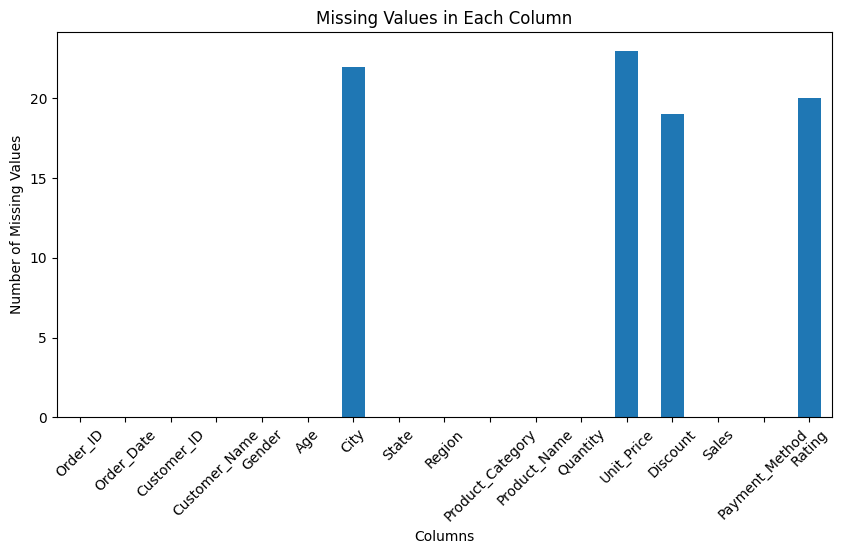

In [11]:
missing_values = df.isnull().sum()

plt.figure(figsize=(10,5))
missing_values.plot(kind='bar')

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [12]:
# Number of duplicate rows
df.duplicated().sum()

np.int64(40)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(1000, 17)

In [16]:
text_columns = [
    "City",
    "Region",
    "Payment_Method",
    "Product_Category",
    "Customer_Name"
]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

print("Text cleaned successfully!")

Text cleaned successfully!


In [17]:
df["Region"].unique()

array(['North', 'South', 'West', 'East'], dtype=object)

In [18]:
df[df["Age"] < 0]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,City,State,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Payment_Method,Rating
58,10058,2025-03-24,C1058,Customer 59,Male,-4,Kolkata,Kolkata State,East,Grocery,Milk,7,4953.0,10.0,31203.90,Debit Card,2.0
180,10180,2025-04-18,C1180,Customer 181,Female,-4,Kolkata,Kolkata State,East,Electronics,Laptop,1,3712.0,10.0,3340.80,Upi,4.0
199,10199,2025-01-01,C1199,Customer 200,Male,-4,Bengaluru,Bengaluru State,South,Furniture,Sofa,1,3343.0,10.0,3008.70,Cash,1.0
266,10266,2025-01-03,C1266,Customer 267,Female,-4,Mumbai,Mumbai State,West,Sports,Football,9,3745.0,0.0,33705.00,Debit Card,2.0
416,10416,2025-04-07,C1416,Customer 417,Male,-4,Delhi,Delhi State,North,Sports,Shoes,2,4357.0,0.0,8714.00,Credit Card,4.0
449,10449,2025-02-04,C1449,Customer 450,Male,-4,Bengaluru,Bengaluru State,South,Grocery,Oil,5,4593.0,15.0,19520.25,Debit Card,5.0
456,10456,2025-02-17,C1456,Customer 457,Female,-4,Lucknow,Lucknow State,North,Electronics,Laptop,1,4482.0,0.0,4482.00,Upi,4.0
498,10498,2025-05-19,C1498,Customer 499,Male,-4,Mumbai,Mumbai State,West,Grocery,Milk,10,2797.0,15.0,23774.50,Upi,5.0
514,10514,2025-05-21,C1514,Customer 515,Male,-4,Bengaluru,Bengaluru State,South,Grocery,Rice,10,153.0,5.0,1453.50,Upi,2.0
530,10530,2025-06-25,C1530,Customer 531,Male,-4,Bengaluru,Bengaluru State,South,Sports,Football,1,2647.0,0.0,2647.00,Debit Card,1.0


In [19]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
City,0
State,0
Region,0
Product_Category,0


In [20]:
# Fill numerical columns with their median
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Unit_Price"] = pd.to_numeric(df["Unit_Price"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Unit_Price"].fillna(df["Unit_Price"].median(), inplace=True)
df["Discount"].fillna(df["Discount"].median(), inplace=True)
df["Rating"].fillna(df["Rating"].median(), inplace=True)

# Fill text columns with the most frequent value (mode)
df["City"].fillna(df["City"].mode()[0], inplace=True)

print("Missing values filled successfully!")

Missing values filled successfully!


/tmp/ipykernel_1202/120855082.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1202/120855082.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [21]:
# Replace discounts greater than 100 with the median discount
median_discount = df.loc[df["Discount"] <= 100, "Discount"].median()

df.loc[df["Discount"] > 100, "Discount"] = median_discount

print("Invalid discounts corrected!")

Invalid discounts corrected!


In [22]:
df["Discount"].describe()

,Discount
count,1000.000000
mean,9.740000
std,6.824879
min,0.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


In [23]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("Date column standardized!")

Date column standardized!


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1000 non-null   int64         
 1   Order_Date        1000 non-null   datetime64[ns]
 2   Customer_ID       1000 non-null   object        
 3   Customer_Name     1000 non-null   object        
 4   Gender            1000 non-null   object        
 5   Age               1000 non-null   int64         
 6   City              1000 non-null   object        
 7   State             1000 non-null   object        
 8   Region            1000 non-null   object        
 9   Product_Category  1000 non-null   object        
 10  Product_Name      1000 non-null   object        
 11  Quantity          1000 non-null   int64         
 12  Unit_Price        1000 non-null   float64       
 13  Discount          1000 non-null   float64       
 14  Sales             1000 non-nul

In [25]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
City,0
State,0
Region,0
Product_Category,0


In [26]:
df.to_csv("Retail_Sales_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [27]:
print("Original Dataset Shape : (1040, 17)")
print("Cleaned Dataset Shape :", df.shape)

Original Dataset Shape : (1040, 17)
Cleaned Dataset Shape : (1000, 17)


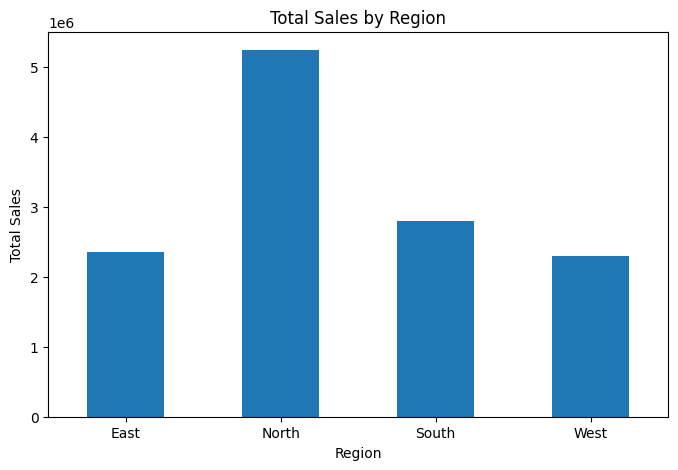

In [28]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

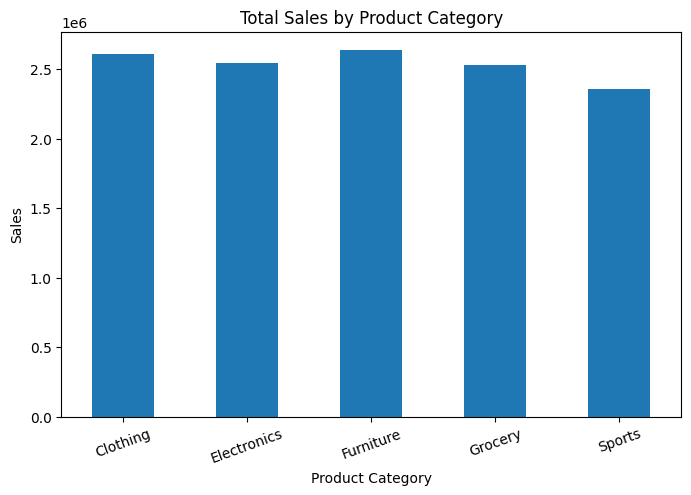

In [29]:
category_sales = df.groupby("Product_Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.xticks(rotation=20)

plt.show()

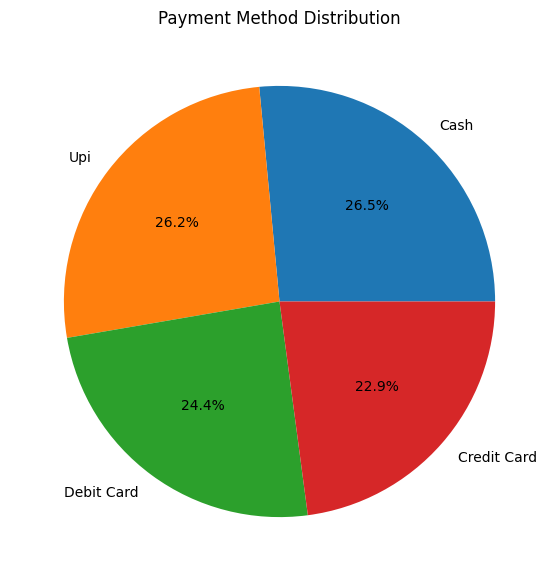

In [30]:
payment = df["Payment_Method"].value_counts()

plt.figure(figsize=(7,7))

payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

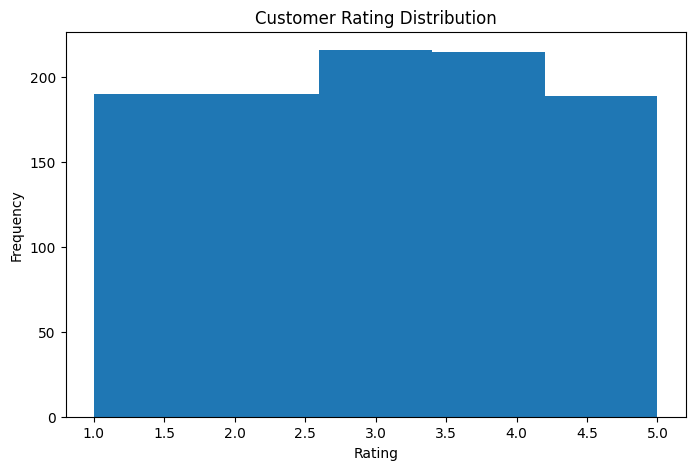

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=5)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

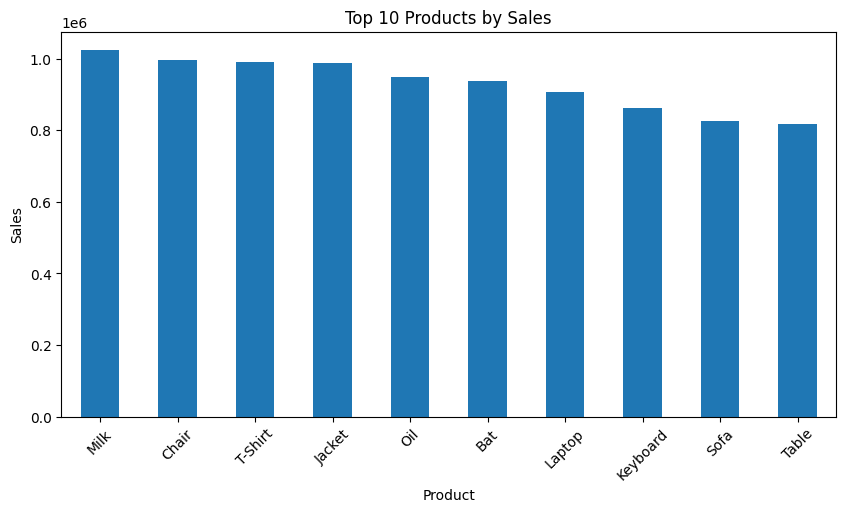

In [32]:
top_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

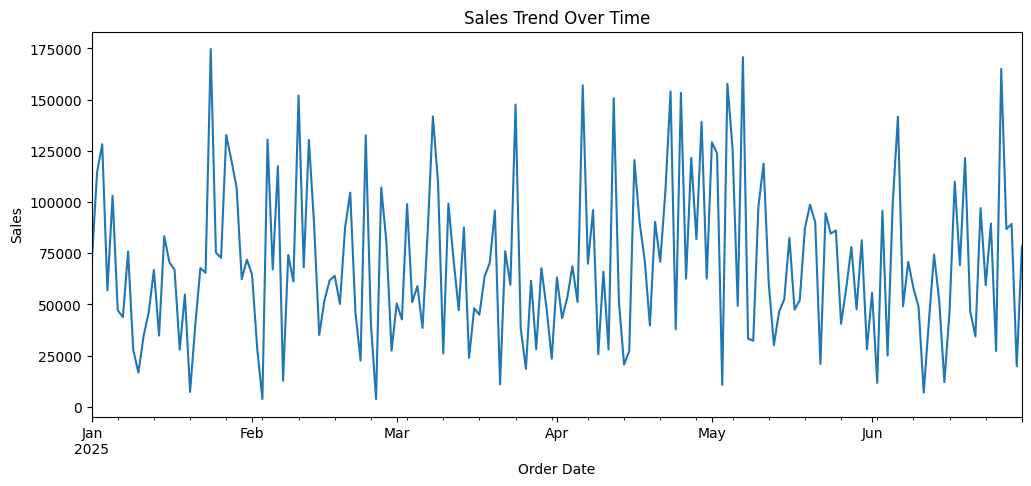

In [33]:
sales_trend = df.groupby("Order_Date")["Sales"].sum()

plt.figure(figsize=(12,5))

sales_trend.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

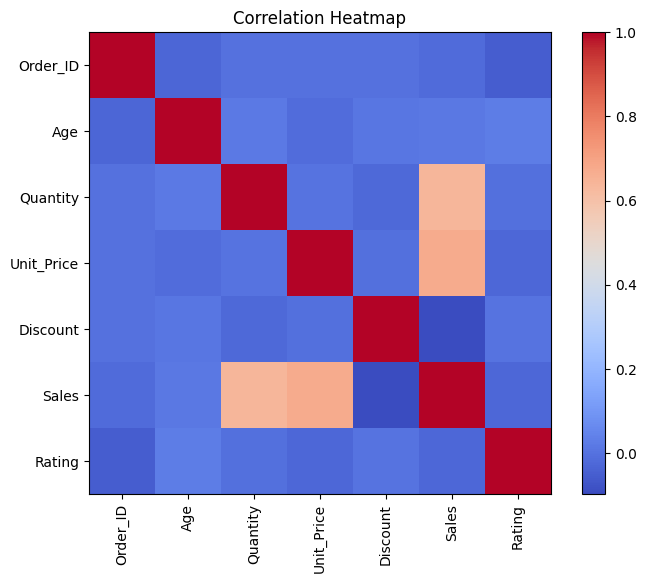

In [34]:
correlation = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
print("=" * 50)
print("DATA CLEANING & REPORTING SUMMARY")
print("=" * 50)

print("\nTotal Records :", len(df))
print("Total Columns :", len(df.columns))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nSummary Statistics")
print(df.describe())

DATA CLEANING & REPORTING SUMMARY

Total Records : 1000
Total Columns : 17

Missing Values
Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Name       0
Gender              0
Age                 0
City                0
State               0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Payment_Method      0
Rating              0
dtype: int64

Duplicate Rows : 0

Summary Statistics
           Order_ID                     Order_Date          Age     Quantity  \
count   1000.000000                           1000  1000.000000  1000.000000   
mean   10499.500000  2025-04-02 00:50:24.000000256    40.309000     5.440000   
min    10000.000000            2025-01-01 00:00:00    -4.000000     1.000000   
25%    10249.750000            2025-02-16 00:00:00    29.000000     3.000000   
50%    10499.500000            2025-04-04 12:00:00    41.000000     5.000000   
75

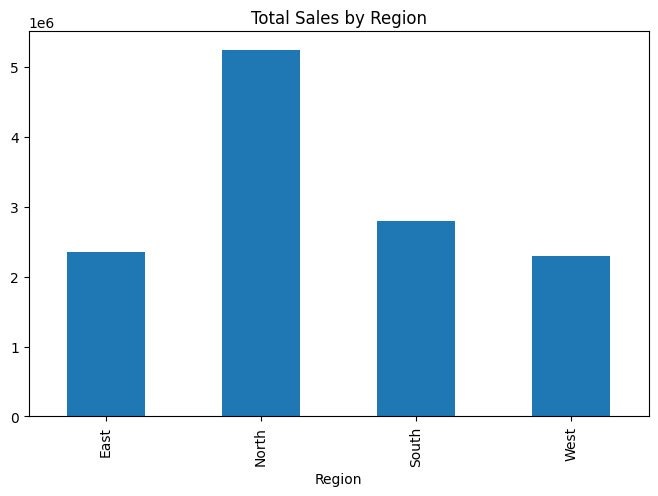

In [36]:
plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")

plt.savefig("Sales_by_Region.png")

plt.show()

In [37]:
from google.colab import files

files.download("Retail_Sales_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>